# **DECODE**🧠⚙️

**DE**tection of **CO**gnitive **D**istortions in **E**xpressions

------------

## **Import Libraries**

We load all essential libraries for data loading, preprocessing, tokenization, modeling, and evaluation.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
import re
import spacy
import math
import torch
import shap
import os
os.environ["WANDB_DISABLED"] = "true"

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# NLTK
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

from collections import Counter, defaultdict
from matplotlib.colors import LinearSegmentedColormap
from gensim.models import Word2Vec
from wordcloud import WordCloud
from multiprocessing import cpu_count
from datasets import Dataset, DatasetDict
from scipy.stats import randint
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    pipeline,
    TrainingArguments
)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Mount Google Drive to load the dataset directly from the cloud storage.

-------

# **1. Data Exploration and Cleaning**

This section provides a quick overview of the dataset structure, including column names, data types, and non-null counts. It also checks for any missing values that may require preprocessing or cleaning.

In [ ]:
# Load the dataset and display its columns along with the first few rows of the 'Patient Question' and 'Dominant Distortion' columns.
df = pd.read_csv('/content/drive/My Drive/DECODE/Annotated_data.csv')
print(df.columns)
df[["Patient Question", "Dominant Distortion"]].head()

Index(['Id_Number', 'Patient Question', 'Distorted part',
       'Dominant Distortion', 'Secondary Distortion (Optional)'],
      dtype='object')


,Patient Question,Dominant Distortion
0,"Hello, I have a beautiful,smart,outgoing and a...",Personalization
1,Since I was about 16 years old I’ve had these ...,Labeling
2,So I’ve been dating on and off this guy for a...,No Distortion
3,My parents got divorced in 2004. My mother has...,No Distortion
4,I don’t really know how to explain the situati...,Fortune-telling


In [ ]:
# Display basic information about the dataset, including column names, data types, and non-null counts.
print(df.info())
# Check for missing values in each column to identify potential data quality issues.
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2530 entries, 0 to 2529
Data columns (total 5 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   Id_Number                        2530 non-null   int64 
 1   Patient Question                 2530 non-null   object
 2   Distorted part                   1597 non-null   object
 3   Dominant Distortion              2530 non-null   object
 4   Secondary Distortion (Optional)  416 non-null    object
dtypes: int64(1), object(4)
memory usage: 99.0+ KB
None
Id_Number                             0
Patient Question                      0
Distorted part                      933
Dominant Distortion                   0
Secondary Distortion (Optional)    2114
dtype: int64


In [ ]:
# Remove unnecessary columns
df = df.drop(columns=['Distorted part', 'Secondary Distortion (Optional)', "Id_Number"])

We drop the columns 'Distorted part', 'Secondary Distortion (Optional)' and 'Id_Number' because they are not required for the main objective of this project, which focuses on classifying the presence or absence of cognitive distortions based on the 'Patient Question' and 'Dominant Distortion'. Removing irrelevant features simplifies the dataset and helps reduce potential noise for the model.

# **Descriptive statistics**

In [ ]:
print(df.describe())

# Distribution of classes in the 'Dominant Distortion' column
print(df['Dominant Distortion'].value_counts())

                                         Patient Question Dominant Distortion
count                                                2530                2530
unique                                               2529                  11
top     I grew up in a upper middle class family. I wa...       No Distortion
freq                                                    2                 933
Dominant Distortion
No Distortion              933
Mind Reading               239
Overgeneralization         239
Magnification              195
Labeling                   165
Personalization            153
Fortune-telling            143
Emotional Reasoning        134
Mental filter              122
Should statements          107
All-or-nothing thinking    100
Name: count, dtype: int64


The `.value_counts()` function displays the distribution of the target variable 'Dominant Distortion', showing the number of samples for each distortion type. This reveals class imbalance in the dataset — for example, 'No Distortion' has the highest count, followed by distortions like 'Overgeneralization' and 'Mind Reading'.

# **Text Length Analysis**

In [ ]:
# Add a column with text length
df['text_length'] = df['Patient Question'].astype(str).apply(len)

# Statistics on text length
print(df['text_length'].describe())

count    2530.000000
mean      869.805138
std       593.128039
min       161.000000
25%       424.250000
50%       654.000000
75%      1159.000000
max      5657.000000
Name: text_length, dtype: float64


The text length statistics reveal that a significant portion of the dataset consists of relatively long texts. This is important to take in consideration to train the machine better in the future.

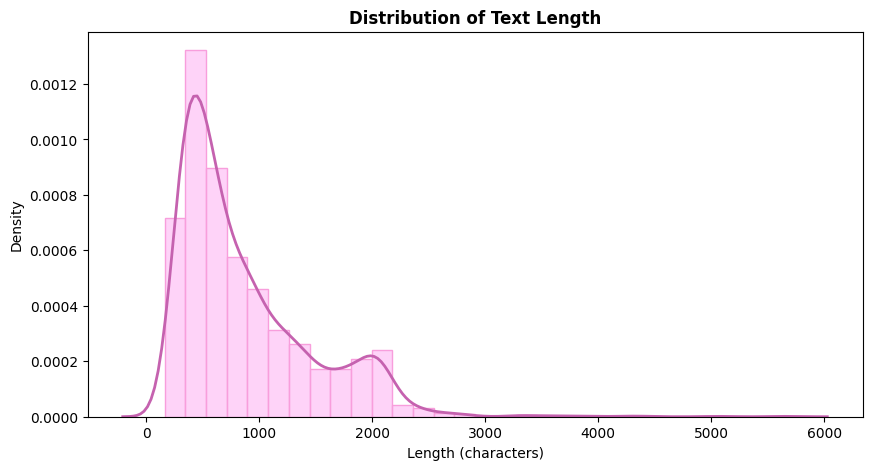

In [ ]:
plt.figure(figsize=(10, 5))
ax = sns.histplot(df['text_length'], bins=30, color='#FEC5F6', edgecolor='#F89EDC', stat='density',)
sns.kdeplot(df['text_length'], color='#C562AF', linewidth=2, ax=ax)
plt.title("Distribution of Text Length", fontweight='bold')
plt.xlabel("Length (characters)")
plt.show()

This histogram with KDE (Kernel Density Estimation) plot visualizes the distribution of text lengths (in characters) in the dataset. The purple bars show the frequency of texts falling into each length bin, while the violet curve smooths the distribution to better show the overall pattern.

## **Data Exploration and Label Preparation**

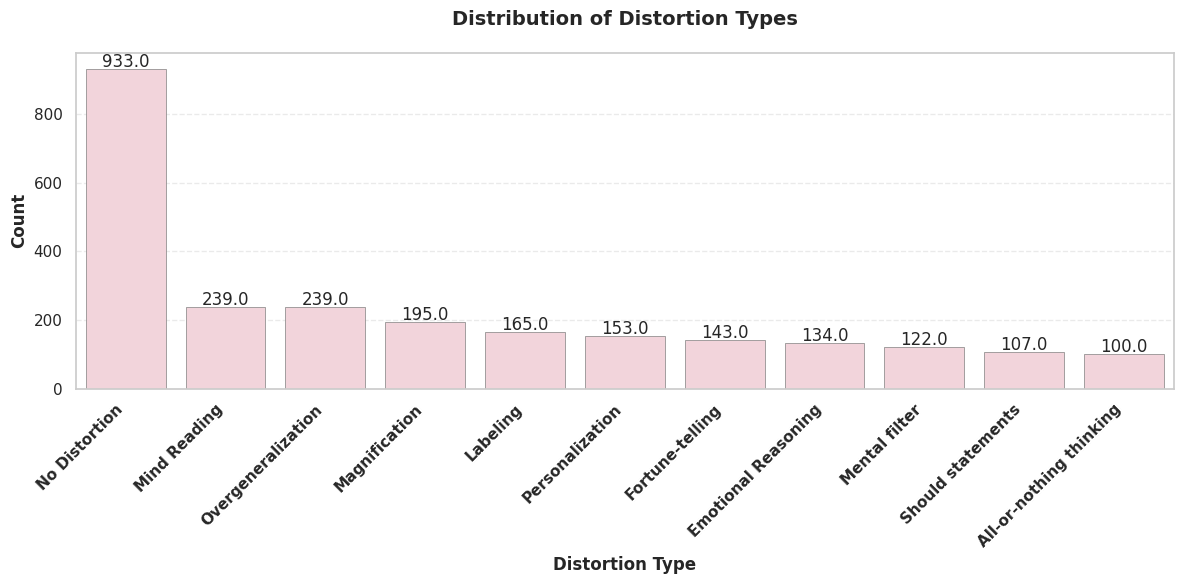

In [ ]:
# bar plot showing the count of each "Dominant Distortion" type in the dataset
sns.set(style="whitegrid", palette="pastel")

plt.figure(figsize=(12, 6))
ax = sns.countplot(
    data=df,
    x='Dominant Distortion',
    order=df['Dominant Distortion'].value_counts().index,
    color='#F7CFD8',
    edgecolor='gray',
    linewidth=0.5
)

plt.title('Distribution of Distortion Types',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Distortion Type', fontweight='bold')
plt.ylabel('Count', fontweight='bold')

plt.xticks(
    rotation=45,
    ha='right',
    fontweight='bold'
)

for p in ax.patches:
    ax.annotate(f'{p.get_height()}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()

ax.yaxis.grid(True, linestyle='--', alpha=0.4)

plt.show()

The graph illustrates the **distribution of different cognitive distortion types identified in the dataset**. The most frequent distortions include Overgeneralization, Mind Reading, and Magnification, followed by Labeling, Personalization, and Fortune-telling. Less common but still significant are Emotional Reasoning, Mental Filter, Should Statements, and All-or-Nothing Thinking.

This visualization highlights the prevalence of **each distortion type**, providing insights into the patterns and frequencies that the NLP model may encounter during binary classification (distortion vs. no distortion).

In [ ]:
# Binary Label Creation
df['label'] = df['Dominant Distortion'].apply(lambda x: 0 if x == 'No Distortion' else 1)

print(df['label'].value_counts())

label
1    1597
0     933
Name: count, dtype: int64


**933** --> "No Distortion" samples (label 0)

**1597** --> "Distortion" samples (label 1)

In [ ]:
# Count the occurrences of 'No Distortion' vs 'Distortion' for binary classification analysis
binary_counts = df['label'].value_counts()  # 'label' column already contains 0 for 'No Distortion', 1 for 'Distortion'

# Calculate the percentage of each binary class
binary_percentages = df['label'].value_counts(normalize=True) * 100

# Print the counts and percentages for binary classes
print(pd.DataFrame({
    'Count': binary_counts,
    'Percentage': binary_percentages.round(2)
}).rename(index={0: 'No Distortion', 1: 'Distortion'}))

               Count  Percentage
label                           
Distortion      1597       63.12
No Distortion    933       36.88


The dataset shows a moderate **imbalance** between the two binary classes: approximately 37% No Distortion and 63% Distortion.
This imbalance should be considered during model training, potentially by applying specific techniques.

/tmp/ipython-input-12-1883063483.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='label', data=df, palette=['#D9A6B5', '#D9A6B5'])


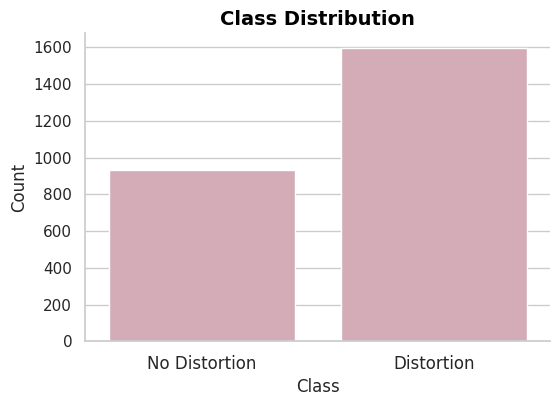

In [ ]:
sns.set(style="whitegrid")

plt.figure(figsize=(6,4))
ax = sns.countplot(x='label', data=df, palette=['#D9A6B5', '#D9A6B5'])

plt.title('Class Distribution', fontsize=14, color='black', weight='bold')
plt.xticks([0, 1], ['No Distortion', 'Distortion'], fontsize=12)
plt.xlabel('Class', fontsize=12)
plt.ylabel('Count', fontsize=12)
sns.despine()

plt.show()

-------------------------------------------------------------------------------------

# **2. PREPROCESSING**

In this phase, the text data undergoes further preprocessing to standardize its format and remove irrelevant tokens that do not contribute to the semantic content of the text.

In [ ]:
# Make all text lowercase
df['Patient Question'] = df['Patient Question'].str.lower()

In [ ]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)
    text = re.sub(r'\@[\w]+', '', text)

    text = re.sub(r'\d+', '', text)

    punctuation = string.punctuation + "“”‘’—–"

    for p in punctuation:
        text = text.replace(p, ' ')

    text = re.sub(r'\s+', ' ', text).strip()

    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]

    return ' '.join(filtered_words)

df['clean_text'] = df['Patient Question'].apply(clean_text)
print(df[['Patient Question', 'clean_text']].head())

                                    Patient Question  \
0  hello, i have a beautiful,smart,outgoing and a...   
1  since i was about 16 years old i’ve had these ...   
2   so i’ve been dating on and off this guy for a...   
3  my parents got divorced in 2004. my mother has...   
4  i don’t really know how to explain the situati...   

                                          clean_text  
0  hello beautiful smart outgoing amazing five ye...  
1  since years old spells impossible control emot...  
2  dating guy almost years years younger relation...  
3  parents got divorced mother never recovered se...  
4  really know explain situation deal lot family ...  


In the initial preprocessing phase of our NLP project, we focused on cleaning the raw text data from patients’ questions to prepare it for a binary classification task aimed at detecting cognitive distortions. We started by converting all text to lowercase to standardize the input. Then, we removed URLs and user mentions, which are irrelevant for the classification.



## **Tokenization**

In this step, the cleaned text is tokenized using a pre-trained tokenizer. Tokenization splits each text into individual tokens and converts them into numerical IDs required by transformer models.

In [ ]:
df['tokens'] = df['clean_text'].apply(word_tokenize)
print(df[['clean_text', 'tokens']].head())

                                          clean_text  \
0  hello beautiful smart outgoing amazing five ye...   
1  since years old spells impossible control emot...   
2  dating guy almost years years younger relation...   
3  parents got divorced mother never recovered se...   
4  really know explain situation deal lot family ...   

                                              tokens  
0  [hello, beautiful, smart, outgoing, amazing, f...  
1  [since, years, old, spells, impossible, contro...  
2  [dating, guy, almost, years, years, younger, r...  
3  [parents, got, divorced, mother, never, recove...  
4  [really, know, explain, situation, deal, lot, ...  


## **Lemmatization**

Then, we apply lemmatization using spaCy to convert each word in the cleaned text to its base or dictionary form. Unlike stemming, lemmatization considers the context and part of speech, producing more linguistically meaningful tokens.

This helps improve the quality of features extracted from the text for subsequent classification tasks. Stopwords and punctuation are filtered out during this process to focus on relevant words.

In [ ]:
nlp = spacy.load("en_core_web_sm")

def spacy_lemmatize(text):
    doc = nlp(text)
    return [token.lemma_ for token in doc if not token.is_punct and not token.is_stop]


df['lemmatized_tokens'] = df['clean_text'].apply(spacy_lemmatize)
print(df[['clean_text', 'lemmatized_tokens']].head())

                                          clean_text  \
0  hello beautiful smart outgoing amazing five ye...   
1  since years old spells impossible control emot...   
2  dating guy almost years years younger relation...   
3  parents got divorced mother never recovered se...   
4  really know explain situation deal lot family ...   

                                   lemmatized_tokens  
0  [hello, beautiful, smart, outgoing, amazing, y...  
1  [year, old, spell, impossible, control, emotio...  
2  [date, guy, year, year, young, relationship, i...  
3  [parent, get, divorced, mother, recover, sever...  
4  [know, explain, situation, deal, lot, family, ...  


&nbsp;

### ***Word Cloud***

To visualize the most frequent words in the dataset, a **Word Cloud** is created. This graphical representation highlights words based on their frequency, providing quick insight into the common terms used in the text data after preprocessing.

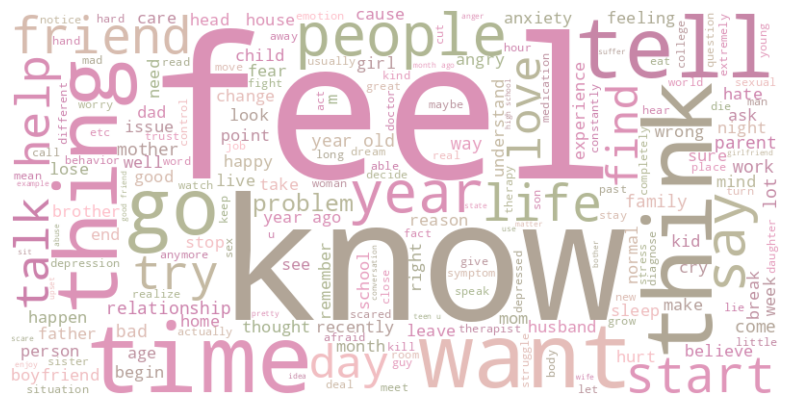

In [ ]:
all_words = ' '.join([' '.join(tokens) for tokens in df['lemmatized_tokens']])
colors = LinearSegmentedColormap.from_list("pink_shades", ["#FFC0CB", "#A5B68D", "#CB80AB", "#E8A0BF"])
# Word Cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap=colors
).generate(all_words)


plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

------------------------------------

# **3. TEXT REPRESENTATION**

After preprocessing the text data, the next step is to transform the cleaned text into numerical representations that can be used by machine learning models. In this phase, we employed three different text representation techniques:  **PPMI, TF-IDF, and Word2Vec**.

## **PPMI**

In [ ]:
window_size = 2
co_occurrence = defaultdict(Counter)

for tokens in df['lemmatized_tokens']:
    for idx, word in enumerate(tokens):
        start = max(idx - window_size, 0)
        end = min(idx + window_size + 1, len(tokens))
        for j in range(start, end):
            if j != idx:
                co_occurrence[word][tokens[j]] += 1

In [ ]:
total_co_occurrences = sum(sum(counter.values()) for counter in co_occurrence.values())
word_counts = Counter()
for word in co_occurrence:
    word_counts[word] = sum(co_occurrence[word].values())

In [ ]:
def compute_ppmi_matrix(co_occurrence, word_counts, total):
    ppmi_matrix = defaultdict(dict)
    for word_i in co_occurrence:
        for word_j in co_occurrence[word_i]:
            pij = co_occurrence[word_i][word_j] / total
            pi = word_counts[word_i] / total
            pj = word_counts[word_j] / total
            if pij > 0:
                pmi = math.log2(pij / (pi * pj))
            else:
                pmi = 0
            ppmi_matrix[word_i][word_j] = max(pmi, 0)
    return ppmi_matrix

ppmi = compute_ppmi_matrix(co_occurrence, word_counts, total_co_occurrences)

In [ ]:
ppmi_df = pd.DataFrame(ppmi).fillna(0)
ppmi_df.head()

,hello,beautiful,smart,outgoing,amazing,year,old,little,girl,yesterday,...,dismissed,protectiveness,shared,noticeably,awkwardly,achieving,lse,perpetual,inc,insecuritie
beautiful,4.191229,0.000000,5.006197,7.761085,0.000000,0.967572,1.862735,3.086304,3.873356,0.00000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0
smart,3.684269,5.006197,5.499237,7.254125,4.481535,0.000000,1.355775,0.000000,0.000000,0.00000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0
friend,0.000000,0.000000,0.000000,0.000000,1.310951,0.050839,0.355116,0.000000,0.932777,0.46883,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,5.083540,0.0,0.0
guy,1.039701,3.361629,0.000000,0.000000,2.836967,0.931520,1.411646,0.000000,1.306790,0.00000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0
year,2.645644,0.967572,0.000000,1.630537,0.000000,0.711493,3.881934,1.000150,1.851333,0.00000,...,0.0,0.0,0.0,0.0,0.0,4.215499,0.0,4.215499,0.0,0.0


The table represents a portion of the PPMI matrix, where each row and column corresponds to a unique word from the vocabulary extracted from the corpus.

Each cell contains the PPMI score between a target word (row) and a context word (column).

Higher PPMI values (e.g., ~7.8) indicate that the two words co-occur more frequently than would be expected by chance, suggesting a strong association in the corpus.

Values of 0.0 mean that the two words either do not co-occur within the chosen window size, or their co-occurrence provides no informative relationship (non-positive PMI).

&nbsp;

To further reduce the dimensionality of the PPMI matrix and extract more meaningful patterns, Singular Value Decomposition (SVD) was applied. SVD helps compress the high-dimensional PPMI vectors into a lower-dimensional space while preserving the most important relationships among words.

In [ ]:
svd = TruncatedSVD(n_components=50, random_state=42)
ppmi_reduced = svd.fit_transform(ppmi_df)

In [ ]:
vocab = ppmi_df.index.tolist()

def document_to_ppmi_vector(tokens, vocab, ppmi_df):
    vector = np.zeros(len(vocab))
    for word in tokens:
        if word in vocab:
            vector += ppmi_df[word].values
    return vector

X_ppmi = np.array([document_to_ppmi_vector(tokens, vocab, ppmi_df) for tokens in df['lemmatized_tokens']])

svd = TruncatedSVD(n_components=50, random_state=42)
X_ppmi_reduced = svd.fit_transform(X_ppmi)

### ***Cosine Similarity***

In [ ]:
# We will compare two random words
word1 = 'anxiety'
word2 = 'stress'

# Before computing similarity, the code checks whether both words exist in the PPMI matrix index, otherwise the code will print a warning message
if word1 in ppmi_df.index and word2 in ppmi_df.index:
    vec1 = ppmi_df.loc[word1].values.reshape(1, -1)
    vec2 = ppmi_df.loc[word2].values.reshape(1, -1)
    similarity = cosine_similarity(vec1, vec2)[0][0]
    print(f"Cosine similarity between '{word1}' and '{word2}': {similarity:.4f}")
else:
    print("One or both words not in vocabulary.")

Cosine similarity between 'anxiety' and 'stress': 0.0902


The resulting similarity score is 0.0888, which indicates a low level of contextual similarity between these two words within the dataset. This suggests that 'anxiety' and 'stress' do not frequently appear in similar contexts based on.

**Cosine Similarity Heatmap**

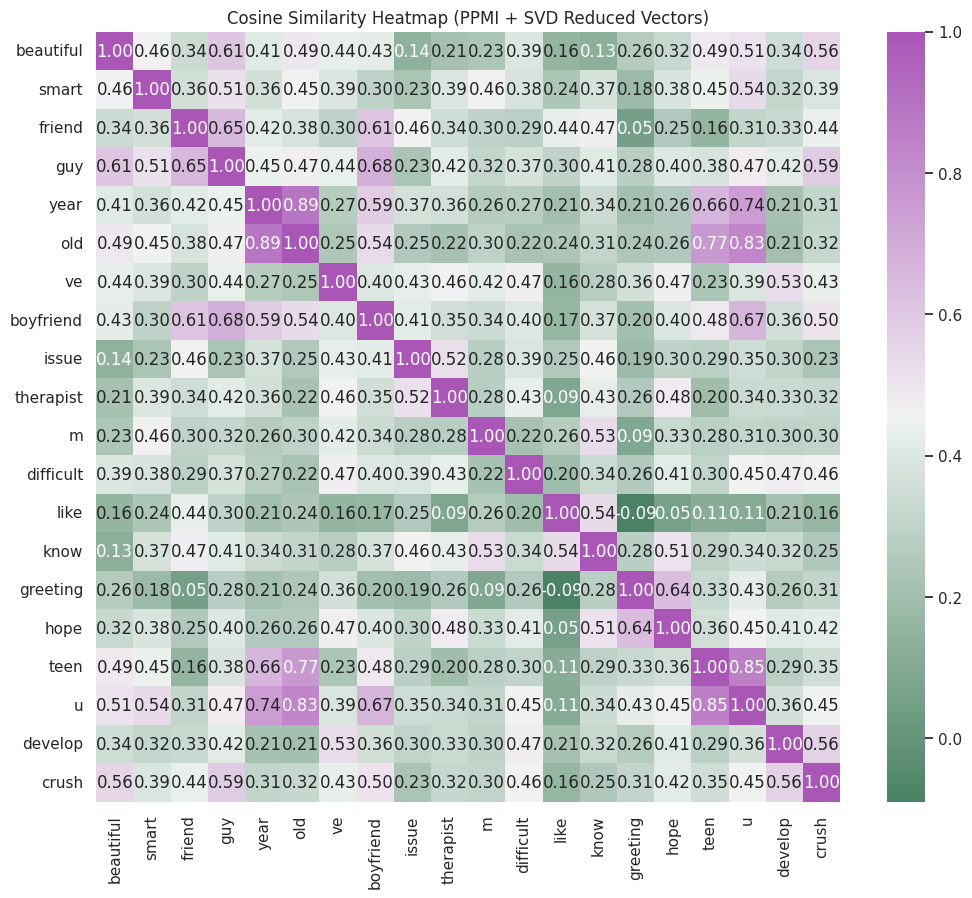

In [ ]:
# random 20 words
selected_words = ppmi_df.index[:20]
selected_indices = [ppmi_df.index.get_loc(w) for w in selected_words]
sub_ppmi_reduced = ppmi_reduced[selected_indices, :]

similarity_matrix = cosine_similarity(sub_ppmi_reduced)
similarity_df = pd.DataFrame(similarity_matrix, index=selected_words, columns=selected_words)

plt.figure(figsize=(12, 10))
cmap = sns.diverging_palette(145, 300, s=60, as_cmap=True)
sns.heatmap(similarity_df, cmap=cmap, annot=True, fmt=".2f")
plt.title("Cosine Similarity Heatmap (PPMI + SVD Reduced Vectors)")
plt.show()

This heatmap visualizes the cosine similarity between word vectors obtained using PPMI and dimensionality reduction via SVD. Values close to 1 indicate strong semantic similarity, while values near 0 (or negative) suggest low or no similarity. For example, boyfriend is highly similar to guy, friend, and crush, whereas issue and greeting show low similarity with most other words. This matrix highlights clusters of related terms and reveals how semantic relationships are preserved in the reduced vector space.


## **TF-IDF**

In [ ]:
vectorizer = CountVectorizer()
X_counts = vectorizer.fit_transform(df['clean_text'])
terms = vectorizer.get_feature_names_out()

# Transform the count matrix into a TF-IDF matrix
transformer = TfidfTransformer(smooth_idf=False)
X_tfidf = transformer.fit_transform(X_counts)
X_tfidf_terms = X_tfidf.T

In [ ]:
# Apply SVD to reduce the dimensionality of the TF-IDF matrix
svd = TruncatedSVD(n_components=30)
tfidf_reduced = svd.fit_transform(X_tfidf_terms)

In [ ]:
# Compute the cosine similarity matrix based on the reduced vectors
sub_tfidf_reduced = tfidf_reduced[selected_indices, :]
similarity_matrix = cosine_similarity(sub_tfidf_reduced)
similarity_df = pd.DataFrame(similarity_matrix, index=selected_words, columns=selected_words)

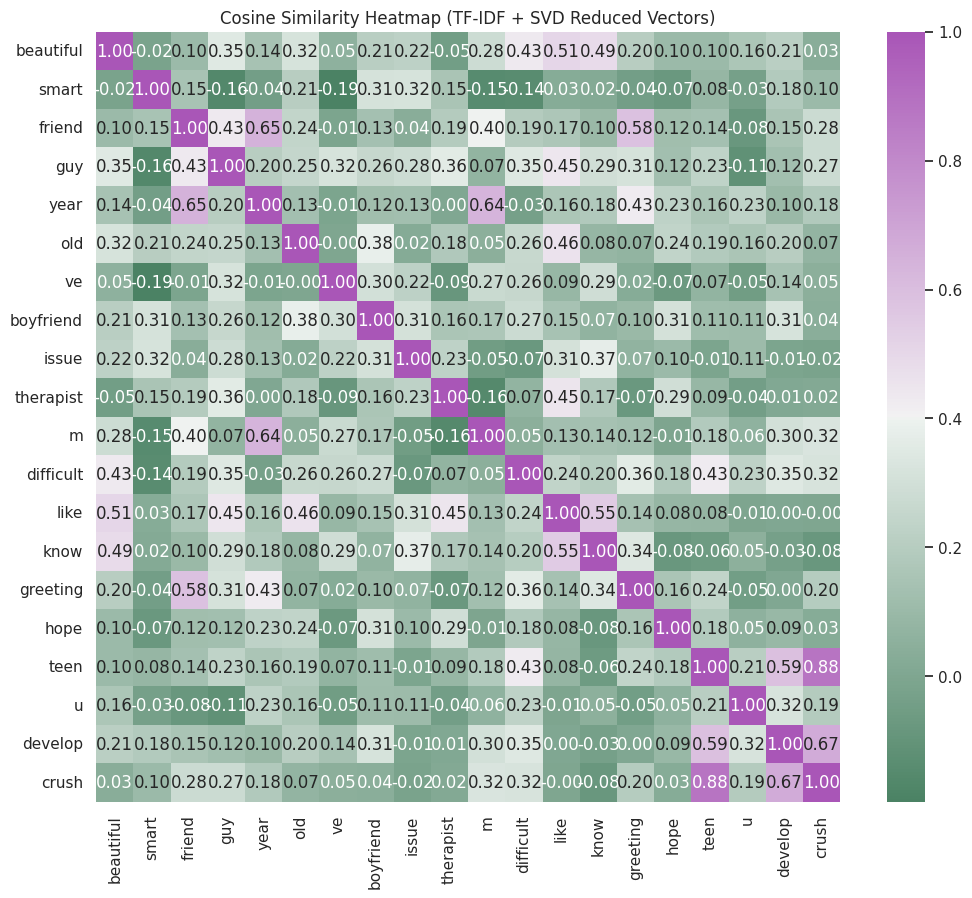

In [ ]:
selected_words = terms[:20]
selected_indices = [np.where(terms == w)[0][0] for w in selected_words]

# Plot the heatmap
plt.figure(figsize=(12, 10))
cmap = sns.diverging_palette(145, 300, s=60, as_cmap=True)
sns.heatmap(similarity_df, cmap=cmap, annot=True, fmt=".2f")
plt.title("Cosine Similarity Heatmap (TF-IDF + SVD Reduced Vectors)")
plt.show()

## **WORD2VEC**

In [ ]:
sentences = df['lemmatized_tokens'].tolist()

w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=3,
    workers=cpu_count(),
    epochs=10
)

w2v_wv = w2v_model.wv

word = 'anxiety'
if word in w2v_wv:
    print(f"Words most similar to '{word}':")
    print(w2v_wv.most_similar(word, topn=10))
else:
    print(f"'{word}' is not in the vocabulary.")

mean_vectors = []
for tokens in df['lemmatized_tokens']:
    vectors = [w2v_wv[word] for word in tokens if word in w2v_wv]
    if vectors:
        mean_vector = np.mean(vectors, axis=0)
    else:
        mean_vector = np.zeros(w2v_model.vector_size)
    mean_vectors.append(mean_vector)

X_w2v = np.array(mean_vectors)

Words most similar to 'anxiety':
[('depression', 0.9457185864448547), ('episode', 0.9352590441703796), ('severe', 0.9296569228172302), ('symptom', 0.9283040165901184), ('extreme', 0.9203513860702515), ('social', 0.9108384847640991), ('prozac', 0.9008147120475769), ('lexapro', 0.8941503763198853), ('dissociative', 0.8878636360168457), ('ocd', 0.887455940246582)]


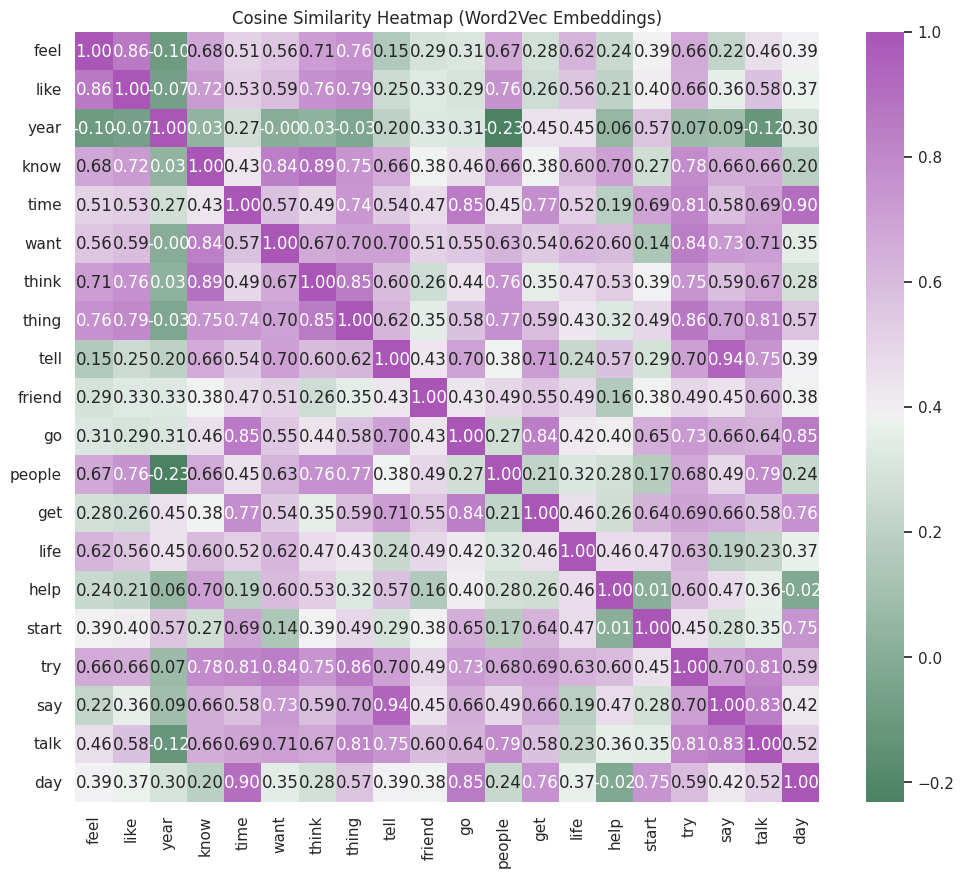

In [ ]:
selected_words = [w for w in w2v_wv.index_to_key[:50] if w.isalpha()][:20]

similarity_matrix = cosine_similarity([w2v_wv[word] for word in selected_words])
similarity_df = pd.DataFrame(similarity_matrix, index=selected_words, columns=selected_words)

plt.figure(figsize=(12, 10))
cmap = sns.diverging_palette(145, 300, s=60, as_cmap=True)
sns.heatmap(similarity_df, cmap=cmap, annot=True, fmt=".2f")
plt.title("Cosine Similarity Heatmap (Word2Vec Embeddings)")
plt.show()

# **Feature matrix and target (X e y)**

• To prepare for classification, we extract feature matrices (X) from our text data using three different representation techniques: TF-IDF, PPMI (reduced with SVD), and Word2Vec (averaged vectors per document).

• Each technique results in a different version of X. We also define a common target variable (y), which contains the labels we want to predict (e.g., the type of cognitive distortion).

• These X and y pairs will later be used to train and evaluate our classifiers.

In [ ]:
y = df["label"]

🔷 PPMI

In [ ]:
X_ppmi = ppmi_reduced

🔷 TF-IDF

In [ ]:
X_tfidf = X_tfidf

🔷 Word2Vec

In [ ]:
X_w2v = np.array(mean_vectors)

-----------------------------------------

# **4. CLASSIFICATION TASK**

After reducing the dimensionality of the PPMI matrix using Singular Value Decomposition (SVD), each document was represented as the average of its word vectors. Documents were then split into training and testing sets using an 80/20 split with stratification.

In [ ]:
vocab = ppmi_df.index.tolist()
word_to_reduced_vector = {word: ppmi_reduced[i] for i, word in enumerate(vocab)}

# Function to convert a document (list of tokens) to a document vector
def document_to_averaged_ppmi_vector(tokens, word_to_reduced_vector, vector_size):
    vectors = [word_to_reduced_vector[word] for word in tokens if word in word_to_reduced_vector]
    if vectors:
        mean_vector = np.mean(vectors, axis=0)
    else:
        mean_vector = np.zeros(vector_size)
    return mean_vector

reduced_vector_size = ppmi_reduced.shape[1]
X_ppmi_documents = np.array([document_to_averaged_ppmi_vector(tokens, word_to_reduced_vector, reduced_vector_size) for tokens in df['lemmatized_tokens']])
X_ppmi = X_ppmi_documents

print(f"Shape of X_ppmi (document vectors): {X_ppmi.shape}")

X = X_ppmi
y = df['label']

print("Class distribution:\n", y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

Shape of X_ppmi (document vectors): (2530, 50)
Class distribution:
 label
1    1597
0     933
Name: count, dtype: int64
Training samples: 2024
Test samples: 506


## **Model Training**

### **Logistic Regression with PPMI**



In [ ]:
clf = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced') #The model was trained with balanced class weights to address class imbalance
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.6818181818181818

Classification Report:
               precision    recall  f1-score   support

           0       0.56      0.70      0.62       187
           1       0.79      0.67      0.73       319

    accuracy                           0.68       506
   macro avg       0.67      0.68      0.67       506
weighted avg       0.70      0.68      0.69       506



### **CONFUSION MATRIX**

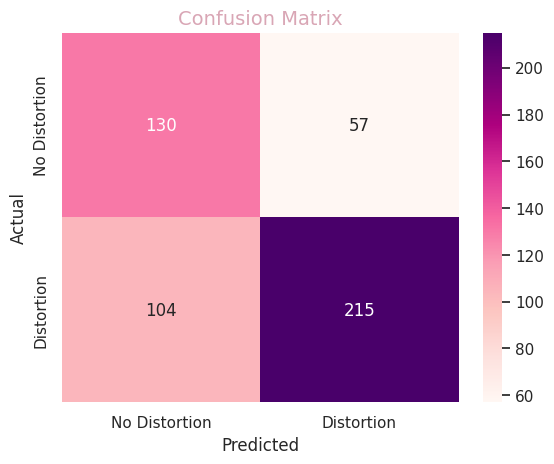

In [ ]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu',
            xticklabels=['No Distortion', 'Distortion'],
            yticklabels=['No Distortion', 'Distortion'])
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix', fontsize=14, color='#D9A6B5')
plt.show()

### **ROC CURVE**

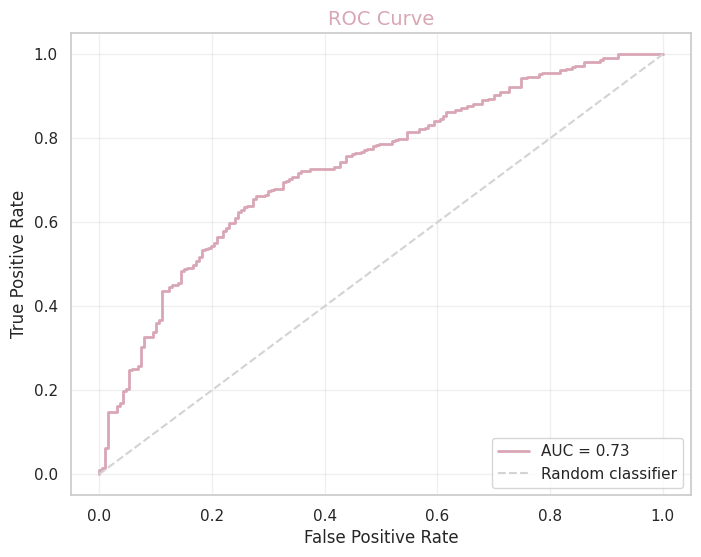

In [ ]:
y_proba = clf.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#D9A6B5', linewidth=2, label=f"AUC = {auc_score:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='lightgray', label='Random classifier')
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve", fontsize=14, color='#D9A6B5', )
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()


## **Logistic Regression with TF-IDF + SVD**

In [ ]:
X = X_tfidf
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")


Training samples: 2024
Test samples: 506


In [ ]:
clf = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.6956521739130435

Confusion Matrix:
[[133  54]
 [100 219]]

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.71      0.63       187
           1       0.80      0.69      0.74       319

    accuracy                           0.70       506
   macro avg       0.69      0.70      0.69       506
weighted avg       0.72      0.70      0.70       506



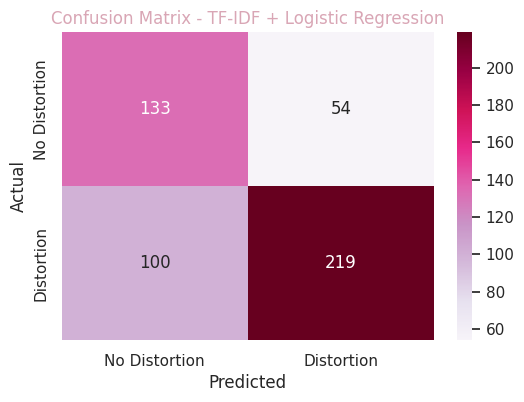

In [ ]:
# Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='PuRd',
            xticklabels=['No Distortion', 'Distortion'],
            yticklabels=['No Distortion', 'Distortion'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - TF-IDF + Logistic Regression', color='#D9A6B5')
plt.show()

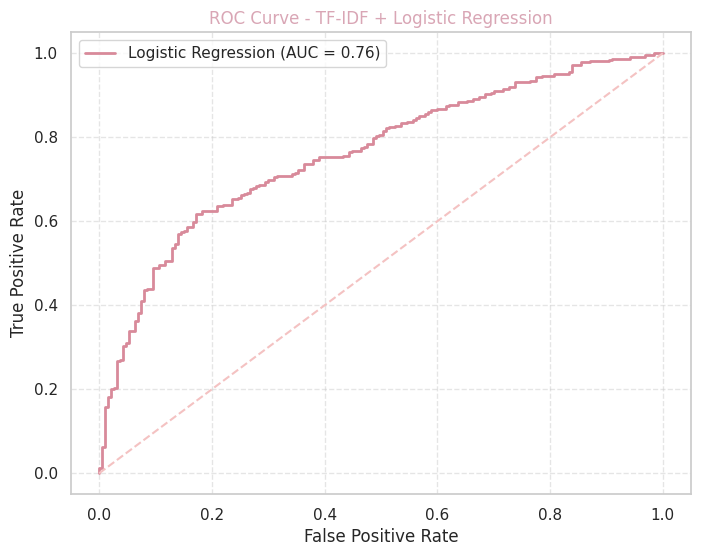

In [ ]:
y_probs = clf.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#D88A9A', linewidth=2, label=f'Logistic Regression (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='#F4C2C2')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - TF-IDF + Logistic Regression', color='#D9A6B5')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


WORD2VEC

In [ ]:
# Feature matrix e target
X = X_w2v
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

clf = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)


Training samples: 2024
Test samples: 506
Accuracy: 0.6640316205533597

Confusion Matrix:
[[127  60]
 [110 209]]


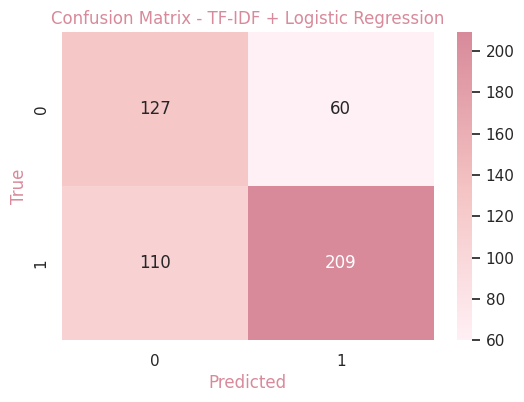


Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.68      0.60       187
           1       0.78      0.66      0.71       319

    accuracy                           0.66       506
   macro avg       0.66      0.67      0.65       506
weighted avg       0.69      0.66      0.67       506



In [ ]:
custom_cmap = LinearSegmentedColormap.from_list(
    "soft_rose", ["#fff0f5", "#f4c2c2", "#d88a9a"]
)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap=custom_cmap)
plt.xlabel('Predicted', color='#D88A9A')
plt.ylabel('True', color='#D88A9A')
plt.title('Confusion Matrix - TF-IDF + Logistic Regression', color='#D88A9A')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

&nbsp;


After testing three different text representation methods—PPMI, Word2Vec, and TF-IDF—we selected TF-IDF as the final choice due to its consistently higher performance in binary classification of cognitive distortions. Among the three, TF-IDF combined with dimensionality reduction (SVD) achieved the best balance between precision and recall, particularly for the minority class (no distortion), which had previously shown lower performance. Additionally, TF-IDF offers better interpretability and simplicity, making it a reliable and efficient choice for our logistic regression model. Given these advantages, we used the TF-IDF representation for further experimentation with alternative classifiers.

SVM + Kernel

In [ ]:
X = X_tfidf
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
svm_clf = SVC(kernel='linear', class_weight='balanced', random_state=42)

# Train the model
svm_clf.fit(X_train, y_train)
y_pred = svm_clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.6996047430830039

Confusion Matrix:
[[128  59]
 [ 93 226]]

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.68      0.63       187
           1       0.79      0.71      0.75       319

    accuracy                           0.70       506
   macro avg       0.69      0.70      0.69       506
weighted avg       0.71      0.70      0.70       506



In [47]:
# Pipeline: SVD -> StandardScaler -> SVM
pipeline = Pipeline([
    ('svd', TruncatedSVD(n_components=100, random_state=42)),
    ('scaler', StandardScaler()),
    ('svm', SVC(class_weight='balanced', random_state=42))
])

# Hyperparameters
param_grid = {
    'svd__n_components': [100, 150, 200],
    'svm__C': [0.1, 1, 10],
    'svm__kernel': ['linear', 'rbf']
}

# Grid search
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best F1 score:", grid_search.best_score_)
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best parameters: {'svd__n_components': 200, 'svm__C': 10, 'svm__kernel': 'rbf'}
Best F1 score: 0.792555562790643


In [48]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.6956521739130435

Confusion Matrix:
[[ 86 101]
 [ 53 266]]

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.46      0.53       187
           1       0.72      0.83      0.78       319

    accuracy                           0.70       506
   macro avg       0.67      0.65      0.65       506
weighted avg       0.69      0.70      0.68       506



RANDOM FOREST

In [49]:
rf_clf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

# Train the model
rf_clf.fit(X_train, y_train)
y_pred = rf_clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.6936758893280632

Confusion Matrix:
[[ 84 103]
 [ 52 267]]

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.45      0.52       187
           1       0.72      0.84      0.78       319

    accuracy                           0.69       506
   macro avg       0.67      0.64      0.65       506
weighted avg       0.68      0.69      0.68       506



In [50]:
rf = RandomForestClassifier(class_weight='balanced', random_state=42)
param_dist = {
    'n_estimators': randint(50, 200),
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': randint(2, 11),
    'min_samples_leaf': randint(1, 5)
}

# Setup RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,               # cross-validation
    scoring='f1',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search.fit(X_train, y_train)

print("Best parameters:", random_search.best_params_)
print("Best F1 score:", random_search.best_score_)

best_rf = random_search.best_estimator_

y_pred = best_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 9, 'n_estimators': 87}
Best F1 score: 0.7925072589043282
Accuracy: 0.7114624505928854

Confusion Matrix:
[[105  82]
 [ 64 255]]

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.56      0.59       187
           1       0.76      0.80      0.78       319

    accuracy                           0.71       506
   macro avg       0.69      0.68      0.68       506
weighted avg       0.71      0.71      0.71       506



------------------------

BERT

In [ ]:
# Hyperparameters
model_name = "roberta-base"
batch_size = 16
epochs = 5
lr = 2e-5
max_len = 512

# Load data
df = pd.read_csv('/content/drive/My Drive/DECODE/Annotated_data.csv')
df['label'] = df['Dominant Distortion'].apply(lambda x: 0 if x == "No Distortion" else 1)
df['cleaned_text'] = df['Patient Question'].astype(str).str.strip().str.replace(r"\s+", " ", regex=True)

# Compute class weights
class_weights_np = compute_class_weight(class_weight='balanced',
                                        classes=np.unique(df['label']),
                                        y=df['label'])
class_weights = torch.tensor(class_weights_np, dtype=torch.float).to('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
# Train/Val split
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)
train_ds = Dataset.from_pandas(train_df[['cleaned_text', 'label']].rename(columns={'cleaned_text': 'text'}))
val_ds = Dataset.from_pandas(val_df[['cleaned_text', 'label']].rename(columns={'cleaned_text': 'text'}))

# Tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=max_len)

train_encoded = train_ds.map(tokenize_function, batched=True)
val_encoded = val_ds.map(tokenize_function, batched=True)

In [ ]:
# Model initialization
id2label = {0: "No Distortion", 1: "Distortion"}
label2id = {"No Distortion": 0, "Distortion": 1}

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    id2label=id2label,
    label2id=label2id
)

# Custom Trainer to use class weights in loss
class WeightedTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        loss_fct = torch.nn.CrossEntropyLoss(weight=self.class_weights)
        loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

# Metrics
def compute_metrics(pred):
    preds = pred.predictions.argmax(-1)
    labels = pred.label_ids
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'precision': precision, 'recall': recall, 'f1': f1}

In [54]:
# Training arguments
output_dir = model_name.replace("/", "-") + "-finetuned-DECODE"
training_args = TrainingArguments(
    output_dir=output_dir,
    num_train_epochs=epochs,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=lr,
    weight_decay=0.01,
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
)

# Initialize trainer
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_encoded,
    eval_dataset=val_encoded,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    class_weights=class_weights
)

# Train
trainer.train()

# Save model
trainer.save_model()

# Evaluate
print("Validation results:")
trainer.evaluate()

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
/tmp/ipython-input-53-2088934750.py:15: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedTrainer.__init__`. Use `processing_class` instead.
  super().__init__(*args, **kwargs)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.524700,0.539683,0.725296,0.723881,0.912226,0.807212
2,0.388400,0.517760,0.770751,0.820189,0.815047,0.817610
3,0.341500,0.553081,0.766798,0.779944,0.877743,0.825959
4,0.258500,0.599512,0.768775,0.815625,0.818182,0.816901
5,0.137200,0.766440,0.758893,0.853047,0.746082,0.795987


Validation results:


{'eval_loss': 0.5177600383758545,
 'eval_accuracy': 0.7707509881422925,
 'eval_precision': 0.8201892744479495,
 'eval_recall': 0.8150470219435737,
 'eval_f1': 0.8176100628930818,
 'eval_runtime': 13.5091,
 'eval_samples_per_second': 37.456,
 'eval_steps_per_second': 2.369,
 'epoch': 5.0}

In [58]:
# Prediction helper
def predict_example(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=max_len, padding="max_length").to(model.device)
    with torch.no_grad():
        outputs = model(**inputs)
    probs = torch.nn.functional.softmax(outputs.logits, dim=1)
    pred = torch.argmax(probs, dim=1).item()
    print(f"\nText: {text[:100]}...")
    print(f"Prediction: {id2label[pred]}")
    print(f"Confidence: {probs[0][pred]:.2%}")

In [59]:
# Test examples
for text in [
    "I always fail at everything",
    "The weather is nice today",
    val_df['cleaned_text'].iloc[0],
    val_df['cleaned_text'].iloc[-1]
]:
    predict_example(text)


Text: I always fail at everything...
Prediction: Distortion
Confidence: 77.81%

Text: The weather is nice today...
Prediction: No Distortion
Confidence: 88.55%

Text: I started self harming when I was 12. I punch myself in the leg as hard as I can. I will often be so...
Prediction: No Distortion
Confidence: 64.33%

Text: Could my boyfriend (age 24) be Bipolar? He does have episodes of depression and acts completely diff...
Prediction: Distortion
Confidence: 78.78%


------------------

In [57]:
from transformers import pipeline
pipe = pipeline("text-classification", model=model, tokenizer=tokenizer, return_all_scores=True)

example_texts = [
    "I always fail at everything",
    "The weather is nice today",
    val_df['cleaned_text'].iloc[0],
    val_df['cleaned_text'].iloc[-1]
]

explainer = shap.Explainer(pipe)

shap_values = explainer(example_texts)
shap.plots.text(shap_values[0])

Device set to use cuda:0
/usr/local/lib/python3.11/dist-packages/transformers/pipelines/text_classification.py:106: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  75%|███████▌  | 3/4 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 5it [00:26, 13.35s/it]
